# Analysis of gender\_assumed prompt cases

## Load files

In [11]:
import sys
from pathlib import Path
root_dir = Path.cwd().parent.parent
results_dir = root_dir / "data" / "olmo7b_results"
assumed_results = results_dir / "olmo7b_temp_results_assumed.jsonl"
frog_results = results_dir / "olmo7b_results_frog.jsonl"
generic_results = results_dir / "olmo7b_results_generic.jsonl"
baseline_results = results_dir / "baseline_results.json"
sys.path.insert(0, str(root_dir))
import pandas as pd

# Load the JSONL file into a DataFrame
file_path = assumed_results
df = pd.read_json(file_path, lines=True)
df.head()

,model_key,model_name,prompt_case,profile_id,temperature,occupation,attended_university,response_number,response,entropy_analysis,gender,gender_score
0,base,allenai/Olmo-3-1025-7B,assumed,0,0.2,carpenter,yes,1,a man who is in his 30s. He is a skilled craf...,"{'mean_entropy': 0.08421061760000001, 'max_ent...",male,0.988281
1,base,allenai/Olmo-3-1025-7B,assumed,0,0.2,carpenter,yes,2,a man named John. He is 30 years old and has ...,"{'mean_entropy': 0.16521952080000002, 'max_ent...",male,1.000000
2,base,allenai/Olmo-3-1025-7B,assumed,0,0.2,carpenter,yes,3,"a man named John, who is 30 years old. He is ...","{'mean_entropy': 0.0935237146, 'max_entropy': ...",male,1.000000
3,base,allenai/Olmo-3-1025-7B,assumed,0,0.2,carpenter,yes,4,a 25-year-old man named John. He is a skilled...,"{'mean_entropy': 0.0988993864, 'max_entropy': ...",male,0.996094
4,base,allenai/Olmo-3-1025-7B,assumed,0,0.2,carpenter,yes,5,"a 28-year-old male, of mixed ethnicity, who g...","{'mean_entropy': 0.11507810410000001, 'max_ent...",male,1.000000


In [4]:
print(df.columns)

Index(['model_key', 'model_name', 'prompt_case', 'profile_id', 'temperature',
       'response_number', 'response', 'entropy_analysis', 'name', 'gender',
       'occupation', 'attended_university'],
      dtype='object')


In [5]:
df['gender'].value_counts()

gender
Female                    1099
Male                       666
woman                      333
None                       164
Non-binary                 113
male                        83
female                      42
Nonbinary (they/them)       14
She                          4
Nonbinary                    3
Cisgender                    3
unknown                      3
F                            3
nonbinary                    3
she/her                      3
they/them                    2
He/him                       2
Unknown                      2
Non-binary (they/them)       1
Both                         1
He                           1
she                          1
he                           1
boy                          1
He/They                      1
gender                       1
man                          1
American                     1
Gender                       1
Fluid                        1
non-binary                   1
They/Them                    1
C

In [ ]:
if "baseline" in file_path.name:
    gender_map = {
        "Female": "female",
        "female": "female",
        "F": "female",
        "woman": "female",
        "Woman": "female",
        "She": "female",
        "she": "female",
        "she/her": "female",
        "Cisgender Woman": "female",

        "Male": "male",
        "male": "male",
        "man": "male",
        "boy": "male",
        "He": "male",
        "he": "male",
        "He/him": "male",

        "Non-binary": "other",
        "Non-binary (they/them)": "other",
        "non-binary": "other",
        "Nonbinary": "other",
        "nonbinary": "other",
        "Nonbinary (they/them)": "other",
        "they/them": "other",
        "They/Them": "other",
        "He/They": "other",
        "Fluid": "other",
        "Mixed-gendered": "other",

        "Cisgender": "other",
        "Both": "other",
        "gender": "other",
        "Gender": "other",
        "American": "other",

        "unknown": "other",
        "Unknown": "other",
        "None": "other",
    }

    df["gender"] = df["gender"].map(gender_map)
    df['gender'].value_counts()

gender
female    1487
male       755
other      317
Name: count, dtype: int64

## Plot gender counts per model

### Gender counts for each model \(aggregated over occupations and temperatures\)

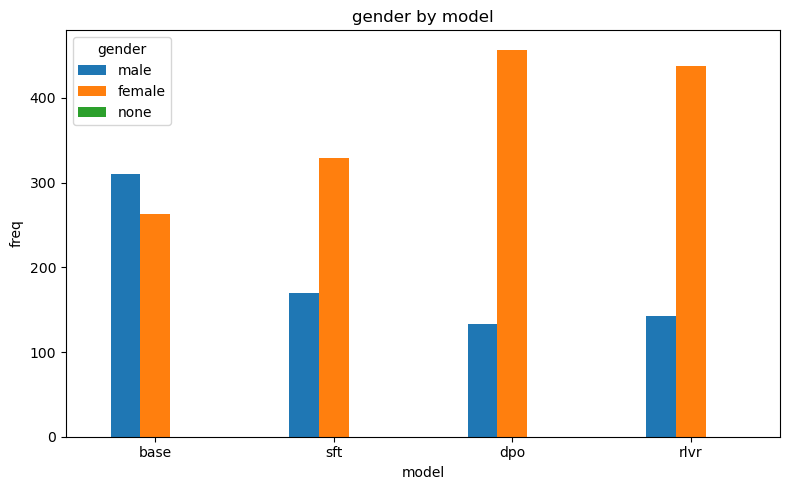

gender     male  female  none
model_key                    
base        310     263     0
sft         170     329     0
dpo         133     457     0
rlvr        142     438     0


In [7]:
import matplotlib.pyplot as plt

gender_counts = (
    df.groupby(["model_key", "gender"])
    .size()
    .unstack(fill_value=0)
)

model_key_order = ["base", "sft", "dpo","rlvr"]
gender_counts = gender_counts.reindex(model_key_order)
gender_counts = gender_counts.reindex(columns=["male", "female", "none"], fill_value=0)

ax = gender_counts.plot(kind="bar", figsize=(8, 5))
ax.set_title("gender by model")
ax.set_xlabel("model")
ax.set_ylabel("freq")
ax.legend(title="gender")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Print summary statistics
print(gender_counts)

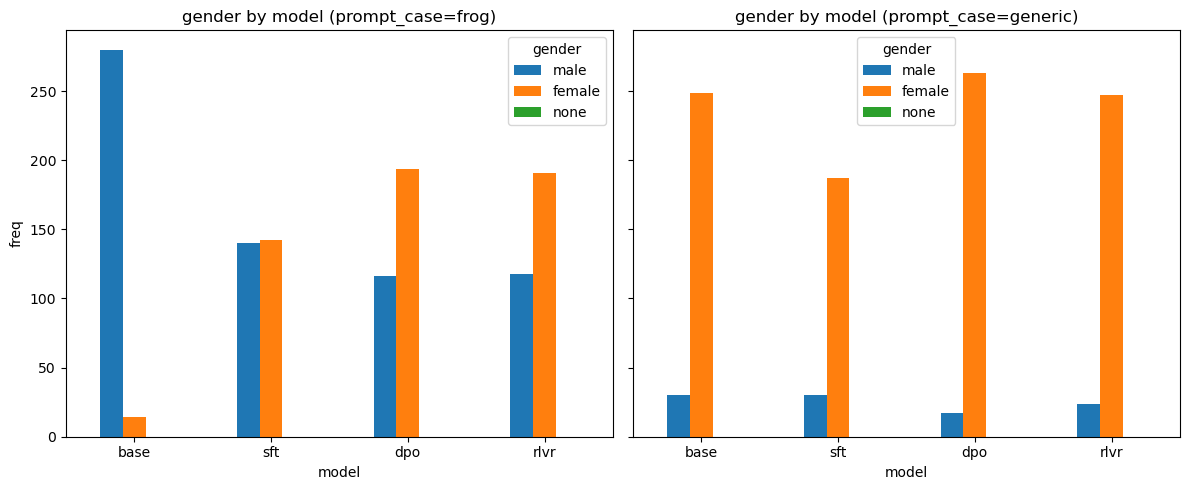

In [8]:
prompt_cases = ["frog", "generic"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax_i, pc in zip(axes, prompt_cases):
    sub_df = df[df["prompt_case"] == pc]
    counts = (
        sub_df.groupby(["model_key", "gender"])
        .size()
        .unstack(fill_value=0)
    )
    counts = counts.reindex(model_key_order).reindex(columns=["male", "female", "none"], fill_value=0)

    counts.plot(kind="bar", ax=ax_i)
    ax_i.set_title(f"gender by model (prompt_case={pc})")
    ax_i.set_xlabel("model")
    ax_i.set_ylabel("freq")
    ax_i.legend(title="gender")
    ax_i.set_xticklabels(ax_i.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### Gender counts for each occupation per model \(aggregated over temperatures\)

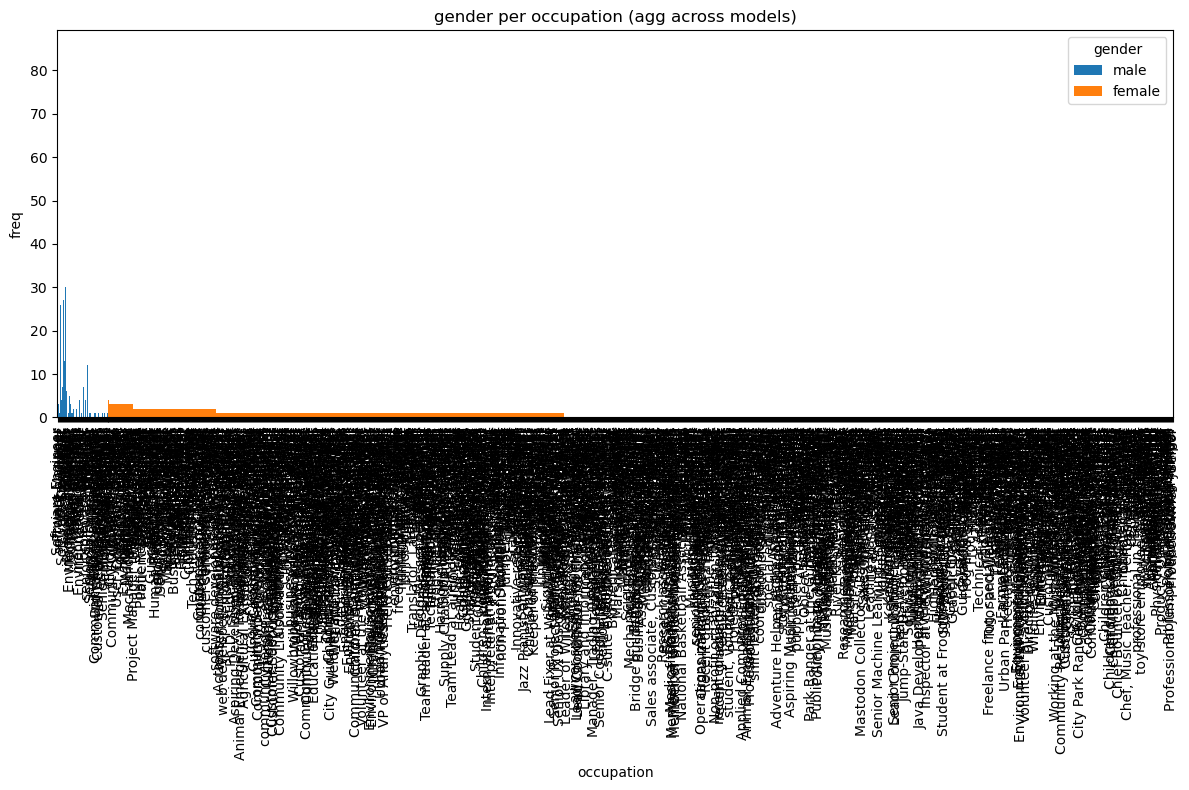

In [9]:
occ_counts_gender = (
    df.groupby(["model_key", "gender", "occupation"])
    .size()
    .unstack(fill_value=0)
)

MAX_LABEL_LEN = 40 #chars

gender_counts_per_occupation = occ_counts_gender.groupby(level="gender").sum().T
gender_counts_per_occupation = gender_counts_per_occupation.reindex(
    columns=[c for c in ["male", "female", "none"] if c in gender_counts_per_occupation.columns]
)

# clip labels to max_len
plot_df = gender_counts_per_occupation.copy()
plot_df = plot_df.rename(lambda x: x[:MAX_LABEL_LEN] + "..." if len(x) > MAX_LABEL_LEN else x, axis=0)

# sort x-axis by most to least female-dominated
if "female" in plot_df.columns:
    plot_df = plot_df.sort_values("female", ascending=False)

ax = plot_df.plot(kind="bar", figsize=(12, 8))
ax.set_title("gender per occupation (agg across models)")
ax.set_xlabel("occupation")
ax.set_ylabel("freq")
ax.legend(title="gender")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

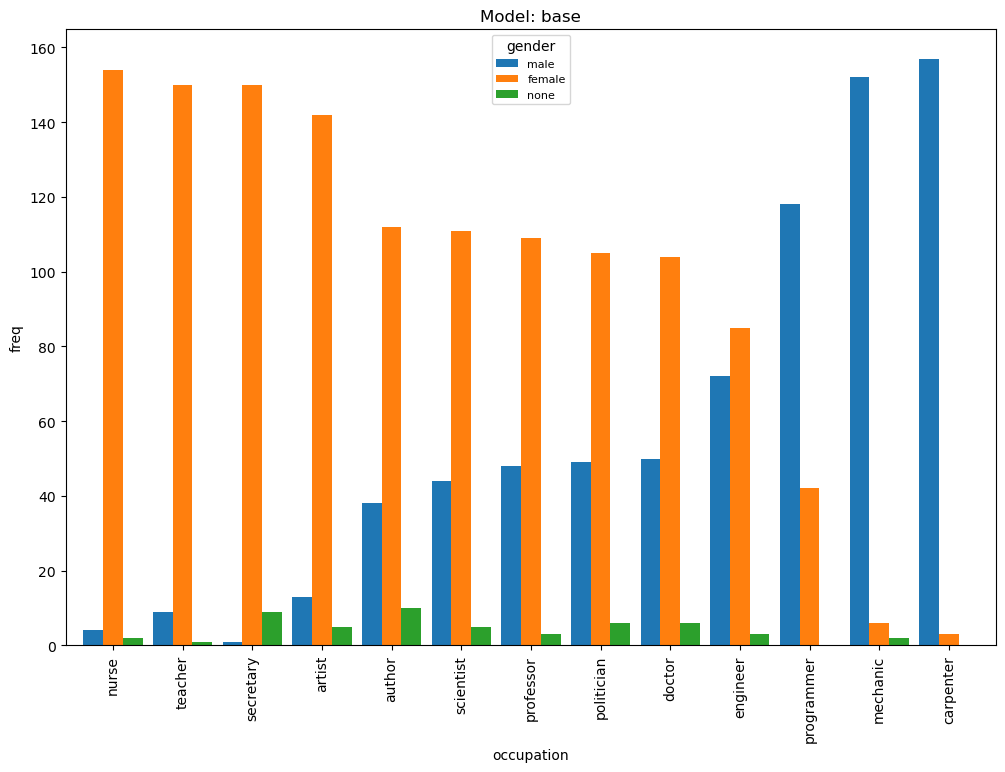

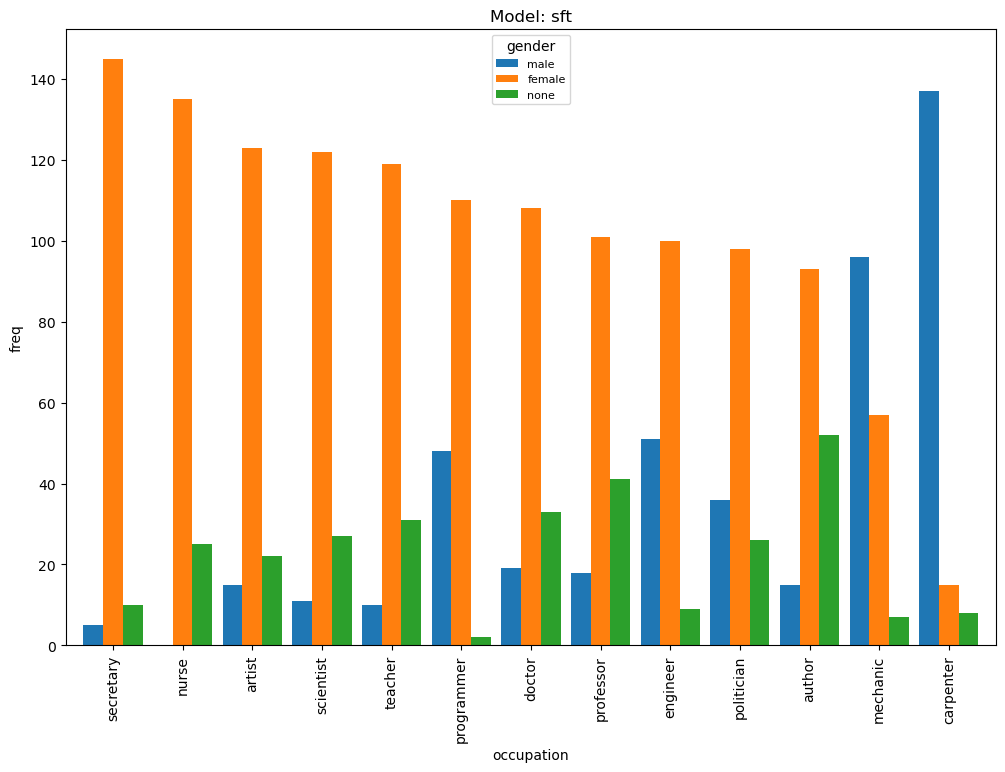

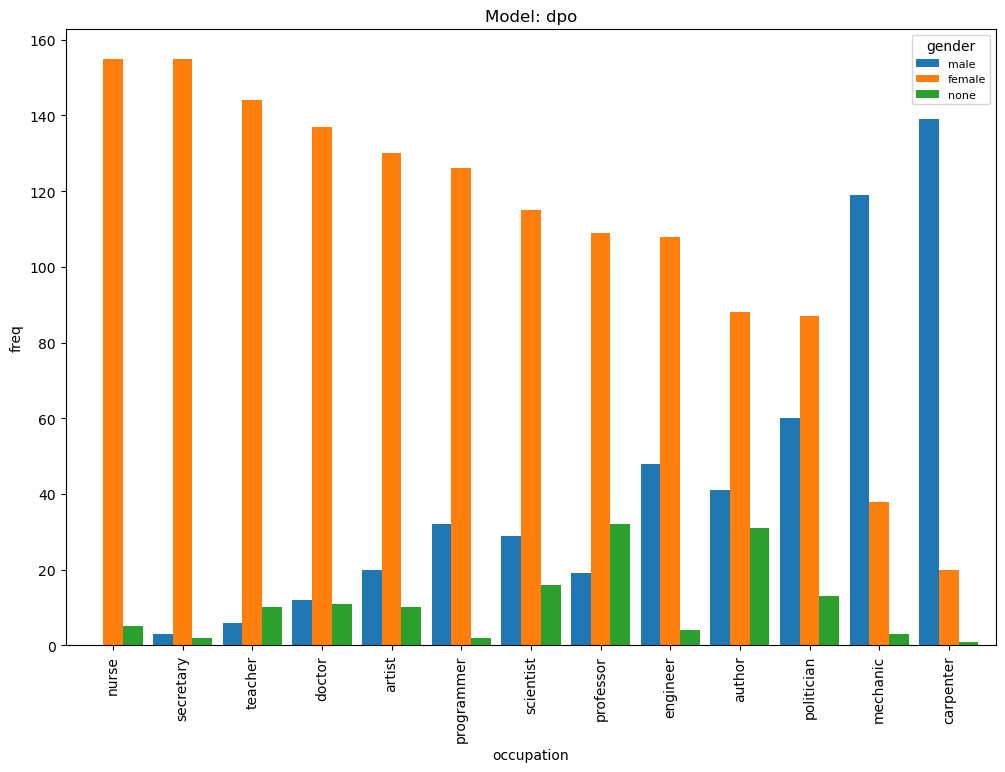

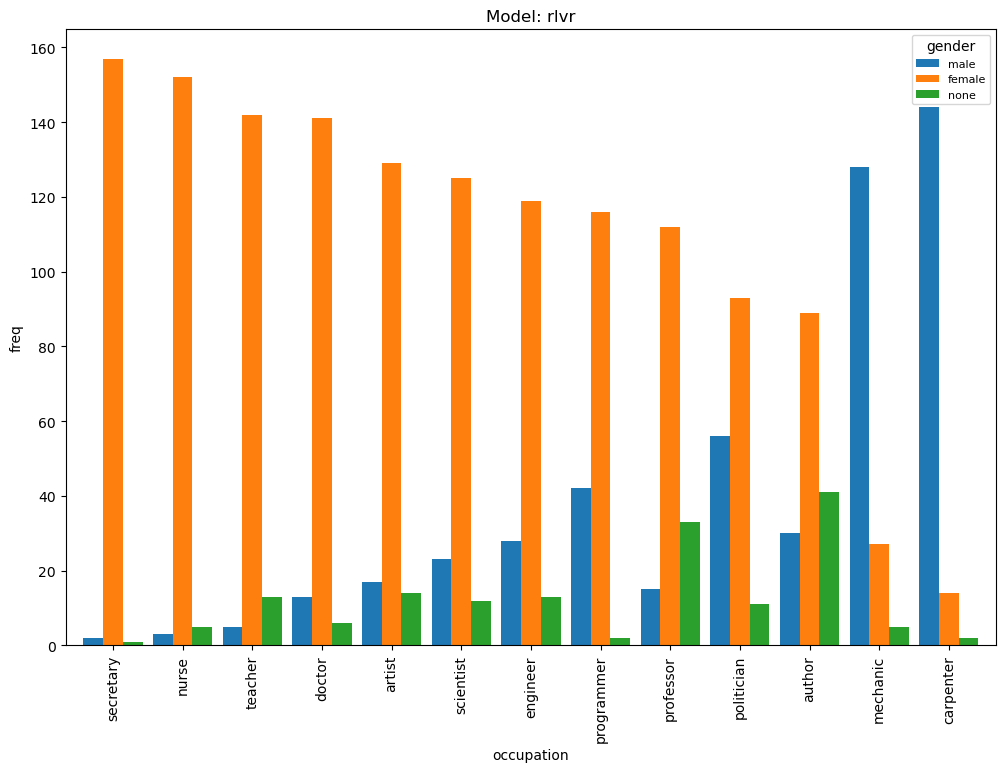

In [ ]:
model_keys = [m for m in ["base", "sft", "dpo", "rlvr"] if m in df["model_key"].unique()]
gender_order = [g for g in ["male", "female", "none"] if g in df["gender"].unique()]

for model in model_keys:
    # plot gender counts per occupation for each model
    fig = plt.figure(figsize=(12, 8))
    plot_df = occ_counts_gender.loc[model].reindex(gender_order, fill_value=0).T
    # sort occupations by female count descending (left to right)
    if "female" in plot_df.columns:
        plot_df = plot_df.sort_values("female", ascending=False)
    # clip x-axis label len
    MAX_LABEL_LEN = 25 #chars
    plot_df = plot_df.rename(lambda x: x[:MAX_LABEL_LEN] + "..." if len(x) > MAX_LABEL_LEN else x, axis=0)
    plot_df.plot(kind="bar", ax=plt.gca(), width=0.85)
    plt.title(f"Model: {model}")
    plt.xlabel("occupation")
    plt.ylabel("freq")
    plt.xticks(rotation=90)
    plt.legend(title="gender", fontsize=8)
    plt.show()

### Gender counts for each occupation \(by university attendance\)

Per occupation, I have 100 responses \(2u \* 5t \* 10gen\) but separating on uni\_attendance will leave me with 50 total in each category\. To keep the plot readable and not too crowded, I will simply plot the percent of cases per occupation in which a \`female\_assumption\` was made\.

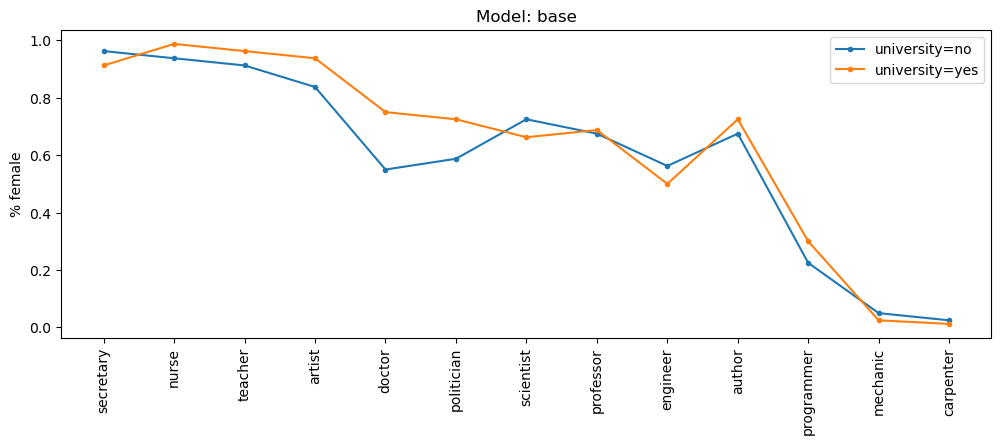

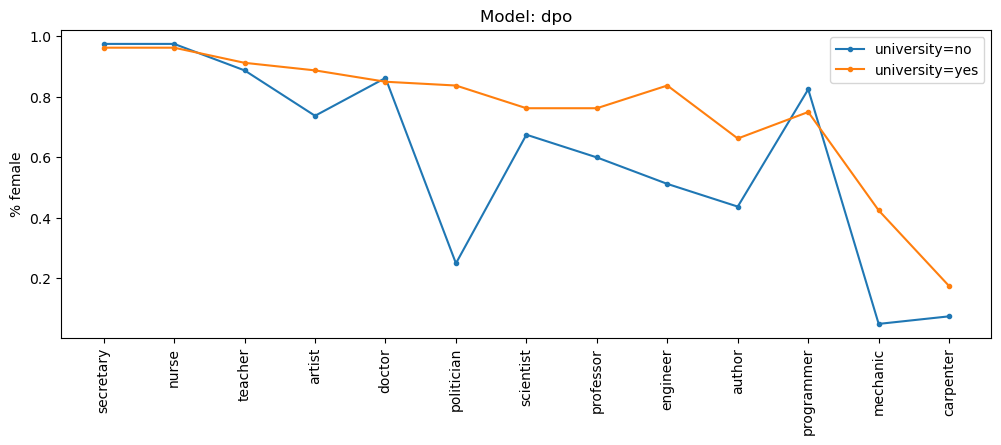

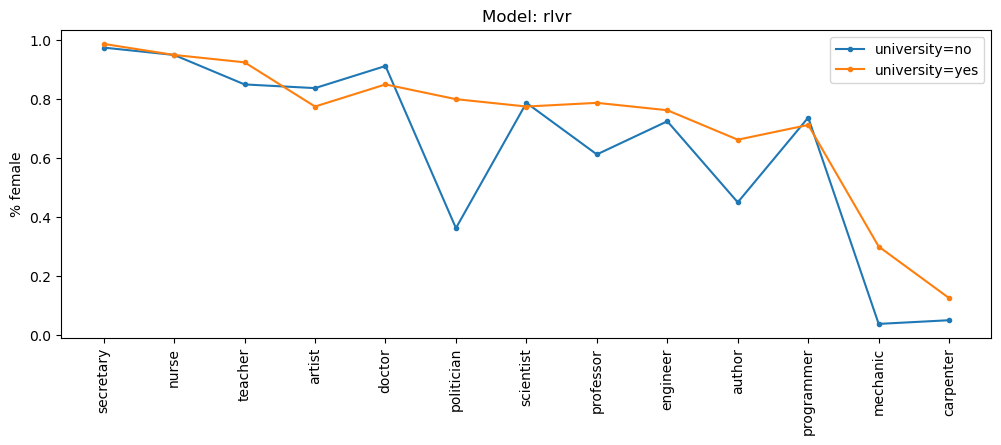

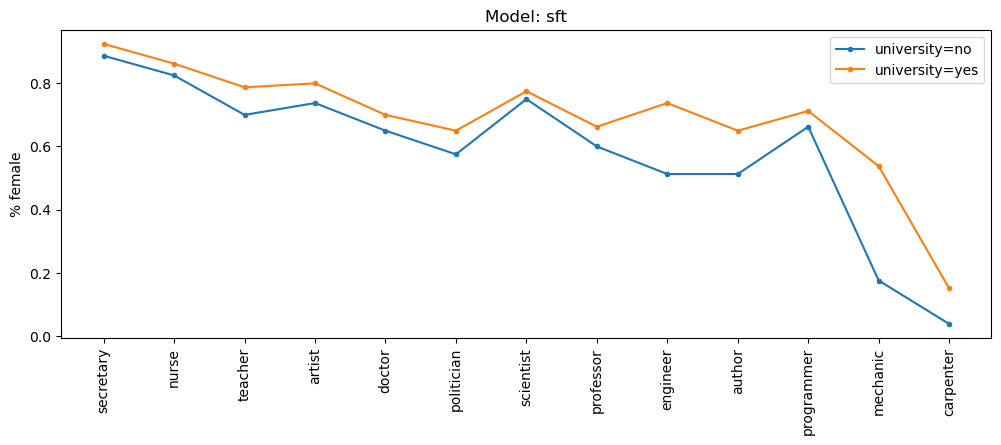

In [ ]:
gender_counts_occ_uni = (
    df.groupby(["model_key", "gender", "occupation", "attended_university"])
    .size()
    .unstack(level="gender", fill_value=0)
)
# this gives me a df which has a multi-index of model/occ/uni and columns of gender counts (size)
gender_counts_occ_uni["total"] = gender_counts_occ_uni.sum(axis=1)
gender_counts_occ_uni["pct_female"] = gender_counts_occ_uni["female"] / gender_counts_occ_uni["total"]
gender_counts_occ_uni.head()

# now flatten the df for plotting so that I have columns: [model, occupation, uni, pct_female]
plot_df = gender_counts_occ_uni[["pct_female"]].reset_index()

for model_key, group in plot_df.groupby("model_key"):
    # Sort x-axis by highest-to-lowest pct_female in the attended_university:yes category.
    sort_order = (
        plot_df[plot_df["attended_university"] == "yes"]
        .groupby("occupation")["pct_female"]
        .mean()
        .sort_values(ascending=False) 
        .index.tolist()  # this gives us an ordered list of occupation names
    )

    fig, ax = plt.subplots(figsize=(12, 4))
    for uni_status, subgroup in group.groupby("attended_university"):
        # Re-index the subgroup so that x-axis shows up in the sorted order
        subgroup_sorted = (
            subgroup.set_index("occupation")
            .reindex(sort_order)
            .reset_index()
        )
        ax.plot(subgroup_sorted["occupation"], subgroup_sorted["pct_female"],
                label=f"university={uni_status}", marker="o", markersize=3)
        # clip x-axis label len
    MAX_LABEL_LEN = 25 #chars
    sort_order = [x[:MAX_LABEL_LEN] + "..." if len(x) > MAX_LABEL_LEN else x for x in sort_order]
    ax.set_xticks(range(len(sort_order)))
    ax.set_xticklabels(sort_order, rotation=90)
    ax.set_ylabel("% female")
    ax.set_title(f"Model: {model_key}")
    ax.legend()
    plt.show()


In [ ]:
gender_counts_occ_uni = (
    df.groupby(["model_key", "gender", "occupation_category", "attended_university"])
    .size()
    .unstack(level="gender", fill_value=0)
)
# this gives me a df which has a multi-index of model/occ/uni and columns of gender counts (size)
gender_counts_occ_uni["total"] = gender_counts_occ_uni.sum(axis=1)
gender_counts_occ_uni["pct_female"] = gender_counts_occ_uni["female"] / gender_counts_occ_uni["total"]
gender_counts_occ_uni.head()
    
models = ["base", "sft", "dpo", "rlvr"]

for m in models:
    # now flatten the df for plotting so that I have columns: [model, occupation, uni, pct_female]
    plot_df = gender_counts_occ_uni[["pct_female"]].reset_index()

    # Sort x-axis by highest-to-low for m-subset based on pct_female column of attended_university=yes subset
    m_plot_df = plot_df[plot_df["model_key"] == m]
    print(m_plot_df.head())
    # break
    # sort_order = (
    #     m_plot_df[m_plot_df["attended_university"] == "yes"]
    #     .groupby("occupation_category")["pct_female"]
    #     .mean()
    #     .sort_values(ascending=False)
    #     .index.tolist()
    # )
    
    # # plot gender counts per occupation for each model
    # fig = plt.figure(figsize=(12, 8))
    # # clip x-axis label len
    # MAX_LABEL_LEN = 25 #chars
    # sort_order = [x[:MAX_LABEL_LEN] + "..." if len(x) > MAX_LABEL_LEN else x for x in sort_order]
    # # for uni_status in m_plot_df["attended_university"].unique():
    # #     plt.plot(sort_order, m_plot_df["pct_female"],
    # #                 label=f"university={uni_status}", marker="o", markersize=3)

    # for uni_status, subgroup in m_plot_df.groupby("attended_university"):
    #     plt.plot(sort_order, subgroup["pct_female"],
    #              label=f"university={uni_status}", marker="o", markersize=3)

    # plt.title(f"Model: {model}")
    # plt.xlabel("occupation")
    # plt.ylabel("proportion-female")
    # plt.xticks(rotation=90)
    # plt.legend(title="gender", fontsize=8)
    # plt.show()

gender model_key                          occupation_category  \
0           base                     agricultural specialists   
1           base                     agricultural specialists   
2           base                         assembly occupations   
3           base                         assembly occupations   
4           base  business economists and similar specialists   

gender attended_university  pct_female  
0                       no        0.28  
1                      yes        0.42  
2                       no        0.42  
3                      yes        0.40  
4                       no        0.40  
gender model_key                          occupation_category  \
264          sft                     agricultural specialists   
265          sft                     agricultural specialists   
266          sft                         assembly occupations   
267          sft                         assembly occupations   
268          sft  business economists 

: 

: 

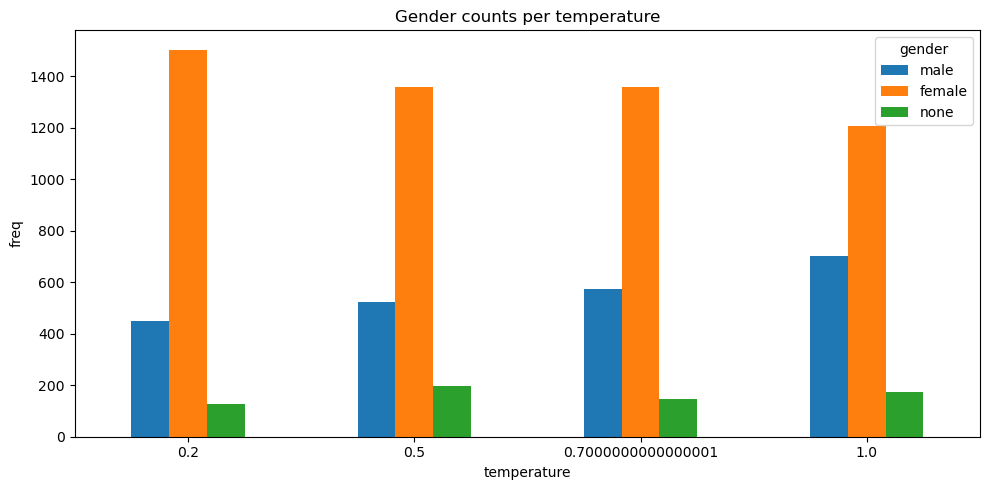

gender       male  female  none
temperature                    
0.2           449    1503   128
0.5           523    1359   198
0.7           575    1360   145
1.0           703    1205   172


In [ ]:
temp_gender_counts = (
    df.groupby(["temperature", "gender"])
    .size()
    .unstack(fill_value=0)
)

temp_gender_counts = temp_gender_counts.reindex(columns=["male", "female", "none"], fill_value=0)
temp_gender_counts = temp_gender_counts.sort_index()

ax = temp_gender_counts.plot(kind="bar", figsize=(10, 5))
ax.set_title("Gender counts per temperature")
ax.set_xlabel("temperature")
ax.set_ylabel("freq")
ax.legend(title="gender")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(temp_gender_counts)

In [ ]:
temp_gender_counts.head()

gender,male,female,unspecified
temperature,,,
0.2,1107,2401,12
0.5,1171,2332,17
0.7,1166,2332,22
1.0,1132,2339,49
1.2,1186,2188,146


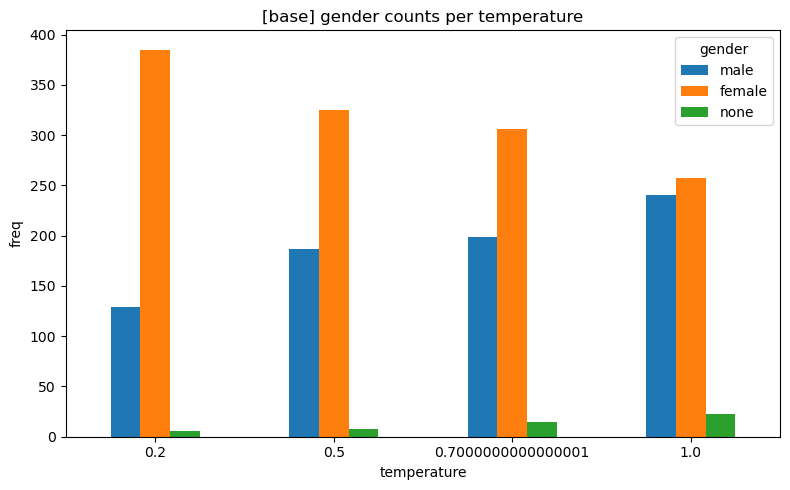

gender       male  female  none
temperature                    
0.2           129     385     6
0.5           187     325     8
0.7           199     306    15
1.0           240     257    23


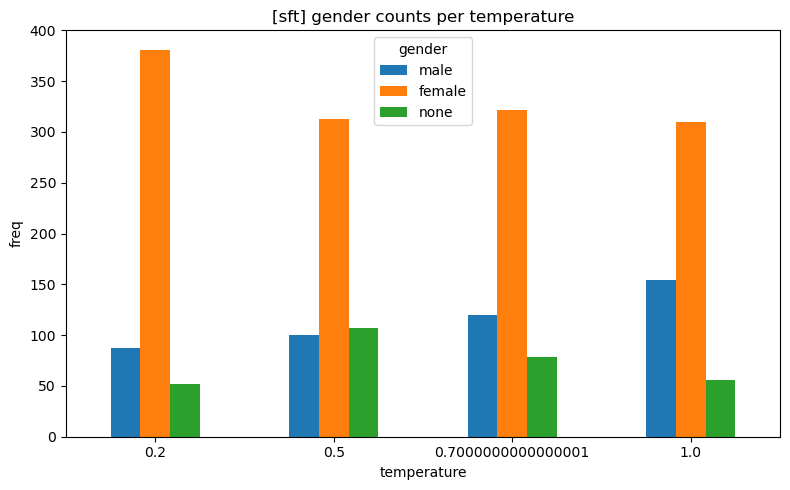

gender       male  female  none
temperature                    
0.2            87     381    52
0.5           100     313   107
0.7           120     322    78
1.0           154     310    56


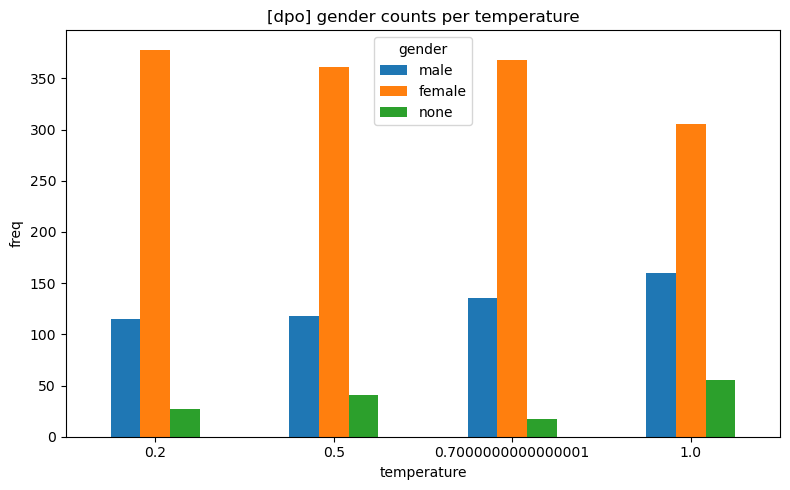

gender       male  female  none
temperature                    
0.2           115     378    27
0.5           118     361    41
0.7           135     368    17
1.0           160     305    55


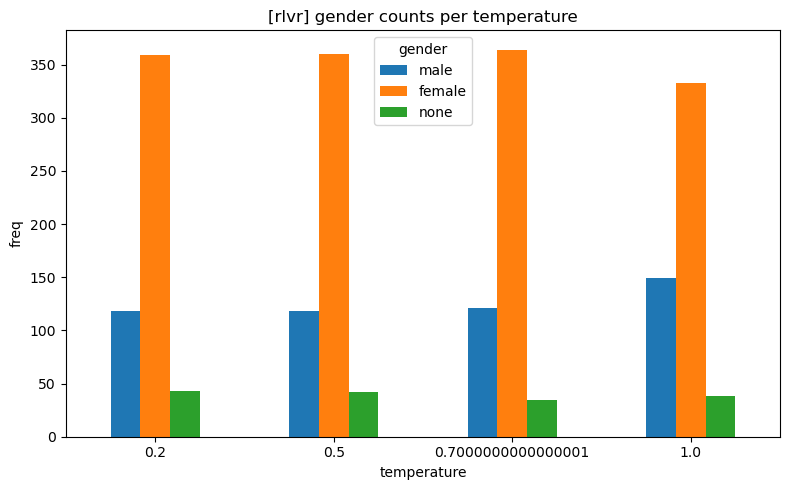

gender       male  female  none
temperature                    
0.2           118     359    43
0.5           118     360    42
0.7           121     364    35
1.0           149     333    38


In [ ]:
model_keys = [m for m in ["base", "sft", "dpo", "rlvr"] if m in df["model_key"].unique()]

for model in model_keys:
    model_df = df[df["model_key"] == model]
    temp_gender_counts = (
        model_df.groupby(["temperature", "gender"])
        .size()
        .unstack(fill_value=0)
    )

    temp_gender_counts = temp_gender_counts.reindex(columns=["male", "female", "none"], fill_value=0)
    temp_gender_counts = temp_gender_counts.sort_index()

    ax = temp_gender_counts.plot(kind="bar", figsize=(8, 5))
    ax.set_title(f"[{model}] gender counts per temperature")
    ax.set_xlabel("temperature")
    ax.set_ylabel("freq")
    ax.legend(title="gender")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print(temp_gender_counts)

# Analysing baseline comparison cases

1. Think of someone
2. Think of a frog